In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
from pyspark.sql import functions as F
from holidays import US
import duckdb as ddb
import xgboost as xgb
import optuna
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [24]:
def create_hist(df, col, sample_fraction=0.1, log=True):
    pdf = df.sample(fraction=sample_fraction, withReplacement=False).select(col).toPandas()
    plt.figure(figsize=(12,6))
    plt.hist(pdf[col], bins=100, color="blue", log=log)
    plt.xlabel(f"{col}")
    plt.ylabel("frequency")
    plt.show()

In [67]:
df = spark.read.parquet("s3a://share/nyc_tlc_trip/*/*.parquet")\
.drop("ehail_fee","store_and_fwd_flag", "trip_type")\
.filter("""
tip_amount >= 0 AND
fare_amount > 0 AND
congestion_surcharge >= 0 AND
trip_distance > 0 AND
total_amount <= 200
""")\
.fillna({"passenger_count":1})

In [27]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- lpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- trip_type: long (nullable = true)
 |-- congestion_surcharge: double (nullable = true)



In [68]:
fee_columns = ["fare_amount","extra","mta_tax","tip_amount","tolls_amount","improvement_surcharge","congestion_surcharge"]

calculated_total = sum(F.coalesce(F.col(c), F.lit(0)) for c in fee_columns)

verified_df = df.filter(calculated_total.between(F.col("total_amount")-1, F.col("total_amount")+1))

print(verified_df.count())
print(df.count())

50495322
69868953


In [69]:
verified_df.describe().show(vertical=True)

-RECORD 0------------------------------------
 summary               | count               
 VendorID              | 50495322            
 RatecodeID            | 50495322            
 PULocationID          | 50495322            
 DOLocationID          | 50495322            
 passenger_count       | 50495322            
 trip_distance         | 50495322            
 fare_amount           | 50495322            
 extra                 | 50495322            
 mta_tax               | 50495322            
 tip_amount            | 50495322            
 tolls_amount          | 50495322            
 improvement_surcharge | 50495322            
 total_amount          | 50495322            
 payment_type          | 50495322            
 congestion_surcharge  | 50495322            
-RECORD 1------------------------------------
 summary               | mean                
 VendorID              | 1.986065758725135   
 RatecodeID            | 3.2042542475518823  
 PULocationID          | 165.75749

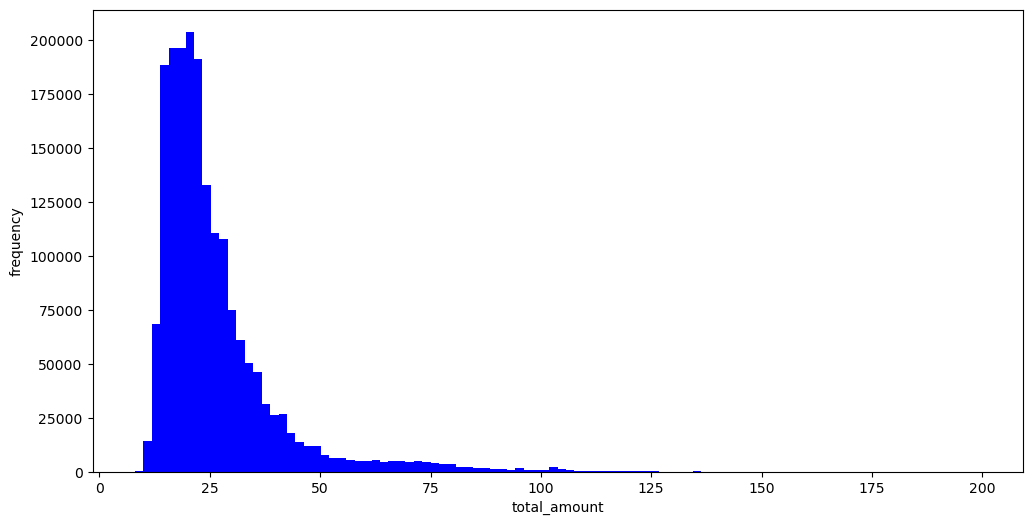

In [39]:
create_hist(verified_df,"total_amount",log=False)

In [70]:
verified_df.createOrReplaceTempView("df")

In [71]:
%%sparksql
INSERT OVERWRITE DIRECTORY 's3a://sandbox/interim/feature.parquet' USING PARQUET
WITH features AS (
    SELECT
        *,
        (unix_timestamp(lpep_dropoff_datetime) - unix_timestamp(lpep_pickup_datetime)) / 60 AS trip_duration_mins
        FROM df
)
SELECT
    *,
    CAST((tip_amount/fare_amount > 0.20) AS INT) AS is_high_tip
FROM
    features
WHERE
    trip_duration_mins > 0 AND
    trip_duration_mins <= 120;

In [75]:
spark.sql(
"""
SELECT
    min(lpep_dropoff_datetime), max(lpep_dropoff_datetime)
FROM
    parquet.`s3a://sandbox/interim/feature.parquet`
"""
).show()

+--------------------------+--------------------------+
|min(lpep_dropoff_datetime)|max(lpep_dropoff_datetime)|
+--------------------------+--------------------------+
|       2009-01-01 00:07:45|       2025-12-01 20:44:42|
+--------------------------+--------------------------+



In [73]:
%%duckdb
SUMMARIZE select
passenger_count,
trip_distance,
trip_duration_mins,
from read_parquet('s3a://sandbox/interim/feature.parquet/*.parquet')

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,passenger_count,BIGINT,0,9,11,1.3172203085626075,0.9823071885158943,1,1,1,1027409,0.0
1,trip_distance,DOUBLE,0.01,84061.55,2589,3.0442283744837835,106.81777670502112,1.2463108100770985,1.9285121961610419,3.275170146379199,1027409,0.0
2,trip_duration_mins,DOUBLE,0.016666666666666666,119.93333333333334,6926,14.30444425410596,10.324297735059337,7.84129570545982,11.910962204940596,17.699090673996512,1027409,0.0


In [77]:
class Holiday:
    def __init__(self, start=2008, end=2026):
        self.holidays = US(years=[start,end], expand=True)

    def __call__(self, date) -> int:
        return int(date in self.holidays)

ddb.create_function("is_holiday", Holiday())

In [79]:
%%duckdb
CREATE OR REPLACE MACRO min_max_scale(col, min_val, max_val) AS 
    (col - min_val)/(max_val - min_val);

CREATE OR REPLACE MACRO ohe(col, val) AS
    CAST(col=val AS INT);

CREATE OR REPLACE MACRO calculate_distance(lat1, lon1, lat2, lon2, p:=2) AS (
    pow(
        pow(abs(lat2-lat1),p) +
        pow(abs(lon2-lon1),p),
        1.0/p
    )
);

,Count


In [80]:
%%duckdb
create or replace table taxi_zones as 
SELECT LocationID, ST_X(center_point) latitude, ST_Y(center_point) longitude, ST_X(center_point_metric) x, ST_Y(center_point_metric) y
FROM 
    (SELECT
     LocationID, ST_Centroid(ST_Transform(geom, 'EPSG:2263', 'EPSG:4326')) AS center_point, ST_Centroid(ST_Transform(geom, 'EPSG:2263', 'EPSG:32118')) AS center_point_metric
     FROM 's3://share/nyc_tlc_trip/taxi_zones/taxi_zones.shp');

select * from taxi_zones limit 10;

,LocationID,latitude,longitude,x,y
0,1,40.691831,-74.174000,285292.401631,58331.749920
1,2,40.616745,-73.831299,314275.555581,49993.016328
2,3,40.864474,-73.847422,312863.383350,77500.272896
3,4,40.723752,-73.976968,301945.841191,61862.265397
4,5,40.552659,-74.188484,284034.961667,42879.761659
5,6,40.600324,-74.071771,293925.243215,48158.171891
6,7,40.761493,-73.919694,306780.801369,66056.149810
7,8,40.778559,-73.923086,306492.731880,67951.055388
8,9,40.751035,-73.787949,317907.851895,64913.339806
9,10,40.678953,-73.790986,317670.390167,56908.253940


In [81]:
%%duckdb
CREATE OR REPLACE TABLE ml_ready_data AS 
select foo.* --exclude(PULocationID,DOLocationID)
, dim1.longitude pu_long, dim1.latitude as pu_lat
, dim2.longitude do_long,dim2.latitude as do_lat
,calculate_distance(dim1.x,dim1.y,dim2.x,dim2.y, p:=2) AS d_euc
,calculate_distance(dim1.x,dim1.y,dim2.x,dim2.y, p:=1) AS d_manh
,calculate_distance(dim1.x,dim1.y,dim2.x,dim2.y, p:=1)/calculate_distance(dim1.x,dim1.y,dim2.x,dim2.y, p:=2) AS d_ratio
,CASE WHEN PULocationID = DOLocationID then 1 else 0 END AS same_location
, 
from 
(SELECT 
    trip_distance/trip_duration_mins AS speed,
    min_max_scale(trip_distance, 0, 50) AS scaled_distance,
    min_max_scale(trip_duration_mins, 0, 120) AS scaled_duration,
    VendorID,
    RatecodeID,
    ohe(payment_type, 1) AS pay_credit,
    ohe(payment_type, 2) AS pay_cash,
    is_high_tip,
    lpep_pickup_datetime AS date,
    is_holiday(lpep_pickup_datetime) AS is_holiday,                      
    PULocationID,
    DOLocationID
FROM read_parquet('s3a://sandbox/interim/feature.parquet/*.parquet')
WHERE PULocationID IS NOT NULL
) foo
join taxi_zones as dim1 on (foo.PULocationID = dim1.LocationID)
join taxi_zones as dim2 on (foo.DOLocationID = dim2.LocationID);

select  * from  ml_ready_data;

,speed,scaled_distance,scaled_duration,VendorID,RatecodeID,pay_credit,pay_cash,is_high_tip,date,is_holiday,PULocationID,DOLocationID,pu_long,pu_lat,do_long,do_lat,d_euc,d_manh,d_ratio,same_location
0,0.489331,0.5580,0.475139,2,5,1,0,1,2024-06-12 17:42:55,0,74,1,-73.937346,40.801169,-74.174000,40.691831,23386.125230,32124.044132,1.373637,0
1,0.286594,0.1582,0.230000,2,1,1,0,0,2025-05-10 09:23:08,0,95,2,-73.847669,40.721432,-73.831299,40.616745,11707.156796,13027.892384,1.112814,0
2,0.194516,0.1608,0.344444,2,1,0,1,0,2025-05-12 15:25:39,0,74,3,-73.937346,40.801169,-73.847422,40.864474,10341.661284,14615.460562,1.413260,0
3,0.361017,0.1420,0.163889,2,1,1,0,1,2025-05-01 21:21:48,0,74,4,-73.937346,40.801169,-73.976968,40.723752,9225.109662,11940.089095,1.294303,0
4,0.567161,0.5354,0.393333,2,1,1,0,0,2024-11-24 03:12:38,0,80,5,-73.936793,40.715370,-74.188484,40.552659,27925.902855,39359.039634,1.409410,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019412,0.177596,0.0724,0.169861,2,1,1,0,1,2025-10-27 16:16:28,0,247,75,-73.924409,40.828988,-73.945750,40.790011,4687.955244,6127.104626,1.306989,0
1019413,0.228821,0.0524,0.095417,2,1,1,0,0,2025-10-25 23:18:30,0,168,75,-73.916822,40.807347,-73.945750,40.790011,3109.076373,4366.907225,1.404567,0
1019414,0.144711,0.0342,0.098472,2,1,1,0,0,2025-10-30 17:16:30,0,263,75,-73.951010,40.778766,-73.945750,40.790011,1325.318563,1692.241688,1.276857,0
1019415,0.317280,0.4168,0.547361,2,1,0,1,0,2024-08-12 14:23:20,0,214,75,-74.085512,40.586787,-73.945750,40.790011,25472.931267,34383.637537,1.349811,0


In [82]:
%%duckdb
COPY ml_ready_data TO 'ml_ready_data_classification.parquet' (FORMAT PARQUET);

,Count
0,1019417


In [84]:
def sin_encode(expr: pl.Expr, *, max_val: int | float) -> pl.Expr:
    """Transform a periodic feature into its sine component."""
    return (expr * (2 * np.pi / max_val)).sin()

def cos_encode(expr: pl.Expr, *, max_val: int | float) -> pl.Expr:
    """Transform a periodic feature into its cosine component."""
    return (expr * (2 * np.pi / max_val)).cos()

### 🔄 Feature Engineering: Cyclic Encoding for Temporal Variables

Time is cyclical, not linear. If we feed raw integers (23:00 and 00:00) into a machine learning model, it interprets a massive 23-hour gap, failing to realize they are actually only 1 hour apart. Tree-based models (XGBoost, LightGBM) struggle to understand this artificial discontinuity.

To solve this, we use **Cyclic Encoding**. By applying Sine and Cosine transformations, we project our temporal features onto a 2D Cartesian plane (a unit circle). This perfectly preserves the true mathematical proximity of continuous time periods.

<pre>
                  y (Sine)
                     ^
               06:00 |
              (0, 1) |
                     |
                     |
 12:00               |               00:00 / 24:00
(-1, 0)--------------+-------------> x (Cosine)
                     |               (1, 0)
                     |
             (0, -1) |
               18:00 |
                     v
</pre>

**Transformation Formulas:**
$x_{sin} = \sin\left(\frac{2 \pi x}{\max(x)}\right)$
$x_{cos} = \cos\left(\frac{2 \pi x}{\max(x)}\right)$

> **Note:** Using *both* sine and cosine is strictly necessary. A single transformation would cause overlapping values (e.g., in a cosine-only encoding, 06:00 and 18:00 would both map to `0`), destroying the model's ability to distinguish morning from evening.


In [87]:
lazy_df = pl.scan_parquet('ml_ready_data_classification.parquet')
lazy_df = lazy_df.with_columns([
    pl.col("date").dt.hour().alias("hour"),
    pl.col("date").dt.weekday().alias("dow"),
]).with_columns([
    sin_encode(pl.col("hour"), max_val=24).alias("hour_sin"),
    cos_encode(pl.col("hour"), max_val=24).alias("hour_cos"),
    sin_encode(pl.col("dow"), max_val=7).alias("dow_sin"),
    cos_encode(pl.col("dow"), max_val=7).alias("dow_cos"),
])

In [90]:
df = lazy_df.drop_nulls().with_columns(pl.selectors.numeric().cast(pl.Float32)).collect().to_pandas()
df.head(5)


,speed,scaled_distance,scaled_duration,VendorID,RatecodeID,pay_credit,pay_cash,is_high_tip,date,is_holiday,...,d_euc,d_manh,d_ratio,same_location,hour,dow,hour_sin,hour_cos,dow_sin,dow_cos
0,0.489331,0.5580,0.475139,2.0,5.0,1.0,0.0,1.0,2024-06-12 17:42:55,0.0,...,23386.125000,32124.044922,1.373637,0.0,17.0,3.0,-0.965926,-0.258819,4.338837e-01,-0.900969
1,0.286594,0.1582,0.230000,2.0,1.0,1.0,0.0,0.0,2025-05-10 09:23:08,0.0,...,11707.157227,13027.892578,1.112814,0.0,9.0,6.0,0.707107,-0.707107,-7.818315e-01,0.623490
2,0.194516,0.1608,0.344444,2.0,1.0,0.0,1.0,0.0,2025-05-12 15:25:39,0.0,...,10341.661133,14615.460938,1.413260,0.0,15.0,1.0,-0.707107,-0.707107,7.818315e-01,0.623490
3,0.361017,0.1420,0.163889,2.0,1.0,1.0,0.0,1.0,2025-05-01 21:21:48,0.0,...,9225.109375,11940.088867,1.294303,0.0,21.0,4.0,-0.707107,0.707107,-4.338837e-01,-0.900969
4,0.567161,0.5354,0.393333,2.0,1.0,1.0,0.0,0.0,2024-11-24 03:12:38,0.0,...,27925.902344,39359.039062,1.409410,0.0,3.0,7.0,0.707107,0.707107,-2.449294e-16,1.000000


In [91]:
cat_cols = ['VendorID', 'RatecodeID', "PULocationID","DOLocationID"]
df[cat_cols] = df[cat_cols].astype('int').astype('category')

print(df.shape)

(1019417, 26)


In [92]:
X = df.drop(columns=["is_high_tip", "pu_long", "pu_lat", "do_long", "do_lat","hour","dow","date"])
y = df["is_high_tip"]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [97]:
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**param,enable_categorical=True)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=4, n_jobs=2)

print("Best Parameters:", study.best_params)

final_model = xgb.XGBClassifier(**study.best_params, enable_categorical=True)
final_model.fit(X,y)

df["predicted_high_tip"] = final_model.predict(X)

[I 2026-03-26 13:06:30,762] A new study created in memory with name: no-name-fa601f7f-618f-4aa6-95ad-4d24532ad643
[I 2026-03-26 13:06:46,167] Trial 1 finished with value: 0.7936915108591159 and parameters: {'max_depth': 6, 'learning_rate': 0.0276288870174551, 'n_estimators': 124}. Best is trial 1 with value: 0.7936915108591159.
[I 2026-03-26 13:07:00,676] Trial 0 finished with value: 0.7947215083086461 and parameters: {'max_depth': 7, 'learning_rate': 0.0150724399200698, 'n_estimators': 205}. Best is trial 0 with value: 0.7947215083086461.
[I 2026-03-26 13:07:15,912] Trial 3 finished with value: 0.7947411273076848 and parameters: {'max_depth': 3, 'learning_rate': 0.09993628800101115, 'n_estimators': 282}. Best is trial 3 with value: 0.7947411273076848.
[I 2026-03-26 13:07:25,431] Trial 2 finished with value: 0.7948735555511958 and parameters: {'max_depth': 8, 'learning_rate': 0.00804095008997685, 'n_estimators': 280}. Best is trial 2 with value: 0.7948735555511958.


Best Parameters: {'max_depth': 8, 'learning_rate': 0.00804095008997685, 'n_estimators': 280}


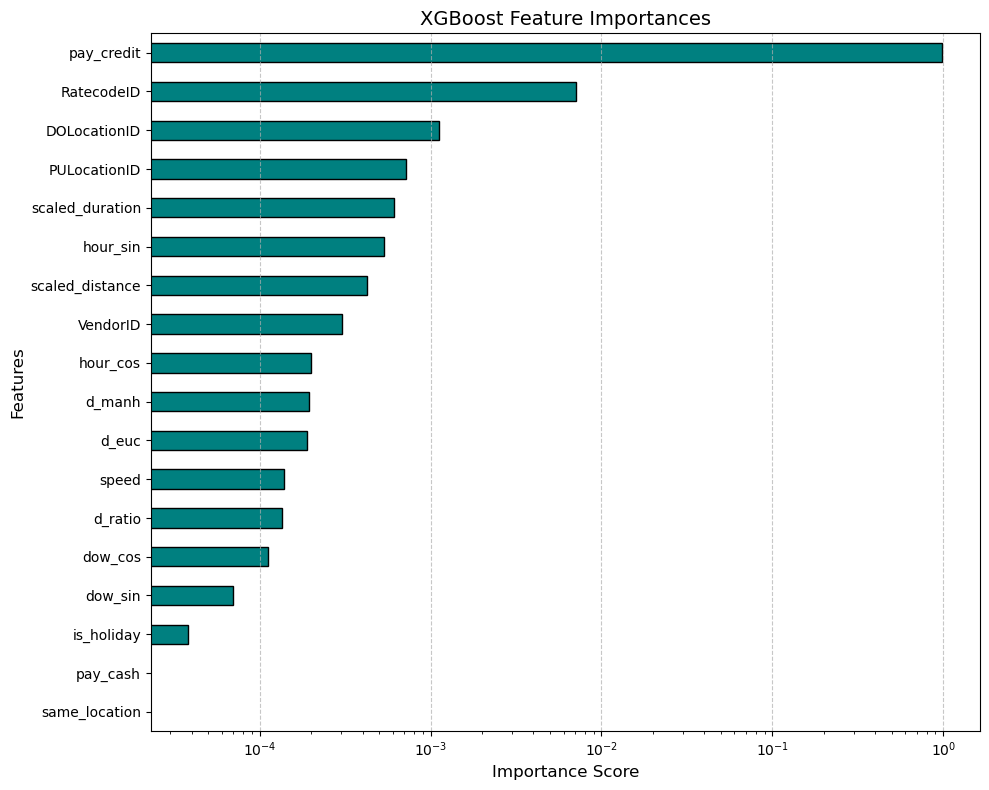

In [98]:
importances = final_model.feature_importances_
feature_names = final_model.feature_names_in_
importance_series = pd.Series(importances, index=feature_names)
importance_series = importance_series.sort_values(ascending=True)

plt.figure(figsize=(10, 8))

importance_series.plot(kind='barh', color='teal', edgecolor='black', logx=True)

plt.title('XGBoost Feature Importances', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [101]:
import pydeck as pdk
df["predicted_high_tip"] = final_model.predict(X)
# Sample down for visualization performance if dataset is massive
viz_sample = df.sample(100, random_state=42)

# Define a color logic: Green [0, 255, 0] for High Tip, Red [255, 0, 0] for Low Tip
viz_sample['color'] = viz_sample['predicted_high_tip'].apply(
    lambda x: [0, 255, 0, 150] if x == 1 else [255, 0, 0, 150]
)

# Create Deck.GL ArcLayer
arc_layer = pdk.Layer(
    "ArcLayer",
    data=viz_sample,
    get_source_position=["pu_long", "pu_lat"],
    get_target_position=["do_long", "do_lat"],
    get_source_color="color",
    get_target_color="color",
    get_width=1,
    pickable=True
)

# Set the viewport to NYC
view_state = pdk.ViewState(
    latitude=40.7580,
    longitude=-73.9855,
    zoom=11,
    pitch=45
)

# Render DeckGL map
r = pdk.Deck(
    layers=[arc_layer],
    initial_view_state=view_state,
    tooltip={"text": "Predicted High Tip: {predicted_high_tip}"}
)
r.to_html("taxi_predictions_map.html")